<a href="https://colab.research.google.com/github/jyesing/HDB_resale_price/blob/main/hdb_resale_price_analysis_and_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [162]:
import pandas as pd

df = pd.read_csv('/content/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv')

df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [163]:
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,228542.000000,228542.000000,2.285420e+05
mean,96.726205,1996.497672,5.282709e+05
std,24.016480,14.333477,1.886565e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.880000e+05
50%,93.000000,1997.000000,4.980000e+05
75%,112.000000,2012.000000,6.350000e+05
max,366.700000,2022.000000,1.700000e+06


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228542 entries, 0 to 228541
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                228542 non-null  object 
 1   town                 228542 non-null  object 
 2   flat_type            228542 non-null  object 
 3   block                228542 non-null  object 
 4   street_name          228542 non-null  object 
 5   storey_range         228542 non-null  object 
 6   floor_area_sqm       228542 non-null  float64
 7   flat_model           228542 non-null  object 
 8   lease_commence_date  228542 non-null  int64  
 9   remaining_lease      228542 non-null  object 
 10  resale_price         228542 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.2+ MB


In [165]:
df.sort_values('month', ascending = False).head(10)

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
224317,2026-04,HOUGANG,4 ROOM,987C,BUANGKOK GREEN,04 TO 06,92.0,Model A,2015,87 years 11 months,653000.0
225659,2026-04,PUNGGOL,4 ROOM,678A,PUNGGOL DR,04 TO 06,93.0,Premium Apartment,2016,89 years 07 months,630000.0
223309,2026-04,BUKIT MERAH,5 ROOM,109A,DEPOT RD,10 TO 12,115.0,Improved,2006,78 years 11 months,900000.0
228010,2026-04,WOODLANDS,5 ROOM,711,WOODLANDS DR 70,04 TO 06,119.0,Improved,1997,70 years,630000.0
223321,2026-04,BUKIT MERAH,5 ROOM,23,JLN MEMBINA,07 TO 09,110.0,Improved,2003,76 years 05 months,1190000.0
228005,2026-04,WOODLANDS,5 ROOM,682A,WOODLANDS DR 62,07 TO 09,120.0,Premium Apartment,2000,72 years 11 months,648000.0
228004,2026-04,WOODLANDS,5 ROOM,694C,WOODLANDS DR 62,10 TO 12,113.0,Improved,2018,91 years 06 months,765888.0
225628,2026-04,PUNGGOL,4 ROOM,299,PUNGGOL CTRL,07 TO 09,94.0,Premium Apartment,2003,76 years 07 months,610000.0
227995,2026-04,WOODLANDS,5 ROOM,899C,WOODLANDS DR 50,07 TO 09,118.0,Improved,1997,70 years 06 months,645000.0
227994,2026-04,WOODLANDS,5 ROOM,892A,WOODLANDS DR 50,04 TO 06,118.0,Improved,1996,69 years 08 months,695000.0


Mission 1: Find the top 5 towns with the highest average resale price in the most recent 12 months.

In [166]:
df['month'] = pd.to_datetime(df['month'])

most_recent_month = pd.to_datetime('2025-12')

start_date_12_months = most_recent_month - pd.DateOffset(months=12)

df_recent_12_months = df[(df['month'] > start_date_12_months) & (df['month'] <= most_recent_month)].copy()

top_5_towns_recent_12_months = df_recent_12_months.groupby('town')['resale_price'].mean().sort_values(ascending = False).head(5)

top_5_towns_recent_12_months

,resale_price
town,
BUKIT TIMAH,963642.000000
BISHAN,864040.521277
CENTRAL AREA,832370.098837
QUEENSTOWN,780897.616331
BUKIT MERAH,763247.357985


Summary: Prices are highest in mature, centrally located towns due to limited supply and sustained demand, not just proximity to the city center.

Mission 2: Which flat_type has the highest price per sqm on average?

In [167]:
df['psm'] = df['resale_price'] / df['floor_area_sqm']
df.groupby('flat_type')['psm'].mean().sort_values(ascending = False)

,psm
flat_type,
1 ROOM,6861.613681
2 ROOM,6655.770462
4 ROOM,5643.576829
3 ROOM,5508.868303
5 ROOM,5355.329563
MULTI-GENERATION,5345.685648
EXECUTIVE,5075.961520


Summary: Smaller flats tend to have higher price per sqm due to a size effect, where fixed housing value is distributed over a smaller area. Buyers of smaller flats are more sensitive to absolute price rather than price efficiency, allowing price per sqm to be higher.

<Axes: xlabel='floor_area_sqm', ylabel='psm'>

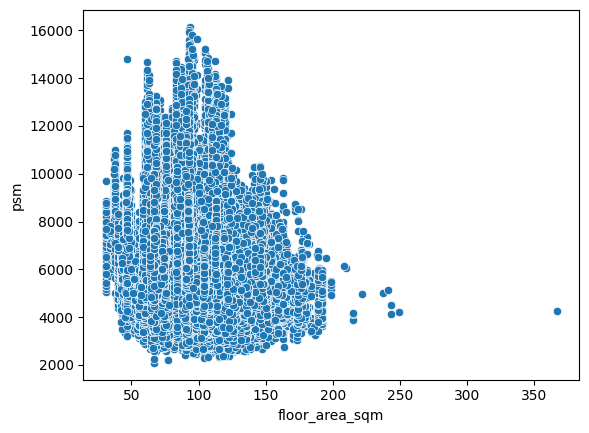

In [168]:
import seaborn as sns
sns.scatterplot(data=df, x='floor_area_sqm', y='psm')

Mission 3: Does storey level affect price?

In [169]:
temp_df_for_storey = df.copy()

temp_df_for_storey[['storey_min_str', 'storey_max_str']] = temp_df_for_storey['storey_range'].str.split(' TO ', expand=True)
temp_df_for_storey['storey_min'] = pd.to_numeric(temp_df_for_storey['storey_min_str'], errors='coerce')
temp_df_for_storey['storey_max'] = pd.to_numeric(temp_df_for_storey['storey_max_str'], errors='coerce')

temp_df_for_storey['storey_level'] = temp_df_for_storey['storey_max']

def categorize_storey(x):
    if pd.isna(x):
        return None
    elif x <= 6:
        return 'Low'
    elif x <= 12:
        return 'Mid'
    else:
        return 'High'

df['storey_category'] = temp_df_for_storey['storey_level'].apply(categorize_storey)

df.groupby('storey_category')['resale_price'].mean().sort_values(ascending=False)

,resale_price
storey_category,
High,630236.141099
Mid,518160.274324
Low,488264.412953


The strong premium for high-floor units likely reflects both functional benefits and lifestyle preferences rather than purely structural differences, such as less noise, better view and more privacy.

Mission 4: Which towns have the fastest price growth from 2017 to latest?

In [170]:
year = df['month'].dt.year
df['year'] = year

yearly_avg_price_by_town = df.pivot_table(values='resale_price', index='year', columns='town', aggfunc='mean')

price_latest_by_town = yearly_avg_price_by_town.loc[2024]
price_2017_by_town = yearly_avg_price_by_town.loc[2017]
town_growth = (price_latest_by_town - price_2017_by_town) / price_2017_by_town
town_growth.sort_values(ascending=False)

,0
town,
YISHUN,0.534167
BUKIT BATOK,0.508249
WOODLANDS,0.500318
CHOA CHU KANG,0.475449
SEMBAWANG,0.473514
SENGKANG,0.465276
PASIR RIS,0.457415
GEYLANG,0.446165
HOUGANG,0.428790


Summary: Higher growth rates in non-central towns are partly driven by a lower starting base, resulting in stronger percentage increases over time.

Mission 5: Does Flat age affects the price?

In [171]:
df['flat_age'] = df['year'] - df['lease_commence_date']

df[['flat_age','resale_price']].corr()

,flat_age,resale_price
flat_age,1.000000,-0.301288
resale_price,-0.301288,1.000000


In [172]:
df['age_group'] = pd.cut(
    df['flat_age'],
    bins=[0,10,20,30,40,50,60,100],
    labels=['0-10','10-20','20-30','30-40','40-50','50-60','60+']
)

df.groupby('age_group')[['resale_price','floor_area_sqm']].mean()

/tmp/ipykernel_1171/3976939645.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')[['resale_price','floor_area_sqm']].mean()


,resale_price,floor_area_sqm
age_group,,
0-10,591334.259084,89.702064
10-20,550062.183361,102.509264
20-30,573058.904214,115.076492
30-40,483915.751329,97.097194
40-50,428208.081177,79.836467
50-60,348240.547456,63.766895
60+,NaN,NaN


Summary: Newer flats tend to have higher resale prices, but the relationship is not strictly linear. The relatively high prices of 20–30 year old flats are largely driven by their larger floor areas rather than age itself. This suggests that floor size is a stronger determinant of resale price than flat age in this range.

Mission 6: Convert remaining_lease into numeric years and compare with flat_age

In [173]:
import re

def convert_lease(x):
  if not isinstance(x, str):
    return 0
  years_match = re.search(r'(\d+) years?', x)
  years = int(years_match.group(1)) if years_match else 0

  months_match = re.search(r'(\d+) months?', x)
  months = int(months_match.group(1)) if months_match else 0

  return years + months / 12

df['remaining_lease_years'] = df['remaining_lease'].apply(convert_lease)

df[['flat_age','remaining_lease_years']].corr()

,flat_age,remaining_lease_years
flat_age,1.000000,-0.999592
remaining_lease_years,-0.999592,1.000000


In [188]:
df['remaining_lease_groups'] = pd.cut(
    df['remaining_lease_years'],
    bins=[20,30,40,50,60,70,80,90, 100],
    labels=['20-30','30-40','40-50','50-60','60-70','70-80', '80-90', '90+']
)

df.groupby('remaining_lease_groups', observed=False)[['resale_price','flat_age']].mean()

,resale_price,flat_age
remaining_lease_groups,,
20-30,NaN,NaN
30-40,326101.687500,59.125000
40-50,362960.885842,51.891428
50-60,440834.124976,43.025537
60-70,492603.932216,34.425125
70-80,567687.703685,23.680272
80-90,575576.483611,14.332423
90+,585327.735121,5.584914


Sumamry: Remaining lease appears more linear because it better aligns with how value is perceived in the market, while flat age groups mix multiple confounding factors such as size and location.

Mission 7: Find outliers, then find which towns dominate these luxury outliers and what flat types are they?

In [175]:
threshold = df['psm'].quantile(0.99)
outlier = df[df['psm'] > threshold]
outlier.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,psm,storey_category,year,flat_age,age_group,remaining_lease_years,remaining_lease_groups
48999,2019-05-01,CENTRAL AREA,4 ROOM,1B,CANTONMENT RD,43 TO 45,93.0,Type S1,2011,90 years 09 months,1030000.0,11075.268817,High,2019,8,0-10,90.750000,90+
51010,2019-06-01,CENTRAL AREA,5 ROOM,1C,CANTONMENT RD,40 TO 42,106.0,Type S2,2011,90 years 07 months,1188000.0,11207.547170,High,2019,8,0-10,90.583333,90+
52952,2019-07-01,CENTRAL AREA,4 ROOM,1F,CANTONMENT RD,49 TO 51,94.0,Type S1,2011,90 years 06 months,1110000.0,11808.510638,High,2019,8,0-10,90.500000,90+
54886,2019-08-01,BUKIT MERAH,4 ROOM,9B,BOON TIONG RD,40 TO 42,92.0,Model A,2016,95 years 05 months,1050000.0,11413.043478,High,2019,3,0-10,95.416667,90+
55001,2019-08-01,CENTRAL AREA,5 ROOM,1C,CANTONMENT RD,40 TO 42,106.0,Type S2,2011,90 years 05 months,1200000.0,11320.754717,High,2019,8,0-10,90.416667,90+


In [176]:
outlier['flat_type'].value_counts().sort_values(ascending=False)

,count
flat_type,
4 ROOM,1339
3 ROOM,513
5 ROOM,414
2 ROOM,11


In [177]:
outlier_pivot = outlier.pivot_table(values='psm', index='town', columns='flat_type', aggfunc='count', margins=True)
outlier_pivot_filled = outlier_pivot.fillna(0)
outlier_pivot_filled

flat_type,2 ROOM,3 ROOM,4 ROOM,5 ROOM,All
town,,,,,
ANG MO KIO,0.0,10.0,45.0,17.0,72
BEDOK,0.0,0.0,3.0,1.0,4
BISHAN,0.0,0.0,16.0,27.0,43
BUKIT MERAH,5.0,143.0,201.0,71.0,420
CENTRAL AREA,0.0,0.0,168.0,76.0,244
CLEMENTI,0.0,16.0,103.0,45.0,164
GEYLANG,0.0,45.0,25.0,5.0,75
KALLANG/WHAMPOA,0.0,81.0,212.0,32.0,325
PUNGGOL,1.0,0.0,0.0,0.0,1


Sumamry: Outliers in price per square meter are concentrated in 4-room flats and primarily located in mature, centrally located towns such as Toa Payoh, Queenstown, and Bukit Merah.

Mission 8: Find undervalued deals

In [192]:
expected = df_recent_12_months.groupby(['town','flat_type'])['resale_price'].transform('median')

df_recent_12_months['price_gap']= df_recent_12_months['resale_price'] - expected
df_recent_12_months['price_gap_pct']= df_recent_12_months['price_gap'] / expected

undervalued = df_recent_12_months[df_recent_12_months['price_gap_pct'] <= -0.2]
undervalued['town'].value_counts()

,count
town,
TOA PAYOH,150
BUKIT MERAH,146
KALLANG/WHAMPOA,143
CLEMENTI,109
BUKIT BATOK,60
QUEENSTOWN,57
WOODLANDS,52
GEYLANG,45
CENTRAL AREA,39


In [193]:
undervalued['flat_type'].value_counts()

,count
flat_type,
4 ROOM,627
3 ROOM,209
5 ROOM,176
EXECUTIVE,12
2 ROOM,2


In [194]:
undervalued[['town','flat_type','resale_price','price_gap_pct']].sort_values('price_gap_pct').head(10)

,town,flat_type,resale_price,price_gap_pct
211974,QUEENSTOWN,4 ROOM,400000.0,-0.595142
202715,CENTRAL AREA,4 ROOM,526000.0,-0.577510
218304,TOA PAYOH,4 ROOM,420000.0,-0.569231
202759,CENTRAL AREA,4 ROOM,548000.0,-0.559839
218302,TOA PAYOH,4 ROOM,430000.0,-0.558974
202714,CENTRAL AREA,4 ROOM,550000.0,-0.558233
216599,TAMPINES,4 ROOM,300000.0,-0.550898
218307,TOA PAYOH,4 ROOM,438000.0,-0.550769
201348,BUKIT MERAH,4 ROOM,420000.0,-0.547414
202718,CENTRAL AREA,4 ROOM,570000.0,-0.542169


Summary: Undervaluation is concentrated in mature towns like Toa Payoh and Kallang/Wjampoa, driven by high price dispersion within similar flat segments.

Mission 9: When did the price surge start?

In [195]:
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,psm,storey_category,year,flat_age,age_group,remaining_lease_years,remaining_lease_groups
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,5272.727273,Mid,2017,38,30-40,61.333333,60-70
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,3731.343284,Low,2017,39,30-40,60.583333,60-70
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,3910.447761,Low,2017,37,30-40,62.416667,60-70
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,3897.058824,Low,2017,37,30-40,62.083333,60-70
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,3955.223881,Low,2017,37,30-40,62.416667,60-70


In [196]:
monthly = df['month'].dt.month
df['monthly'] = monthly


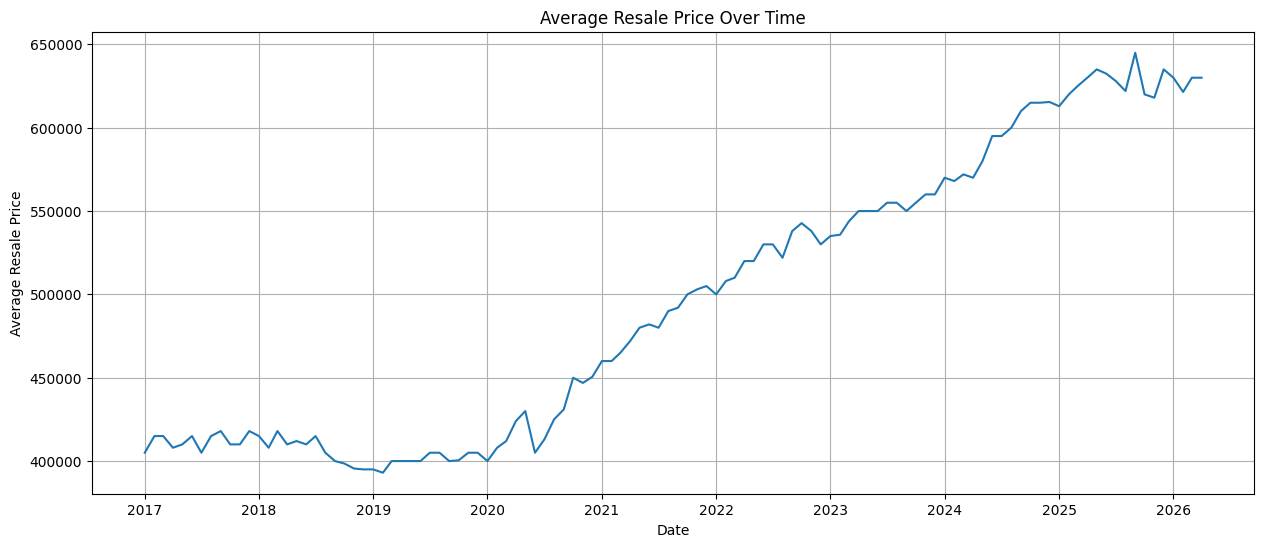

In [197]:
monthly_avg_price = df.groupby(['year', 'monthly'])['resale_price'].median().reset_index()
monthly_avg_price['date'] = pd.to_datetime(monthly_avg_price['year'].astype(str) + '-' + monthly_avg_price['monthly'].astype(str))

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_avg_price, x='date', y='resale_price')
plt.title('Average Resale Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Resale Price')
plt.grid(True)
plt.show()

In [198]:
baseline = monthly_avg_price[monthly_avg_price['year'] == 2019]['resale_price'].median()
peak = monthly_avg_price['resale_price'].max()
pct_increase = (peak - baseline) / baseline * 100
pct_increase

61.25000000000001

Summary: The monthly resale price trend shows a relatively stable period from 2017 to mid of 2018, followed by a slight dip during mid of 2018 to 2020. The price surge begins around mid-2020 and accelerates significantly after 2021. Comparing the pre-COVID baseline in 2019 to the peak period, resale prices increased by approximately 61.25%, indicating a strong post-pandemic structural shift in the HDB market.

Mission 10: Build a simple price prediction model

In [199]:
features = ['floor_area_sqm','town','flat_type','storey_category', 'remaining_lease_groups']
df_model = pd.get_dummies(df[features + ['resale_price']], drop_first=True)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df_model.drop('resale_price', axis=1)
y = df_model['resale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [200]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 91909.71597693498
R2: 0.6339587718265535


In [201]:
def predict_price(town, flat_type, storey, floor_area_sqm, remaining_lease_group):
    new_flat = pd.DataFrame([
        {
            'town': town,
            'flat_type': flat_type,
            'storey_category': storey,
            'floor_area_sqm': floor_area_sqm,
            'remaining_lease_groups': remaining_lease_group,
        }
    ])

    new_flat = pd.get_dummies(new_flat)
    new_flat = new_flat.reindex(columns=X.columns, fill_value=0)

    return model.predict(new_flat)[0]

predict_price('PUNGGOL','4 ROOM','Mid', 95, '80-90')

np.float64(498625.1712968457)

Summary: Based on the trained model, a Punggol 4-room flat on a mid floor with 95 sqm and 80–90 years of remaining lease is estimated to have a resale value of approximately $500K, representing the expected market price given similar property characteristics.